# 00 - Comprensión Inicial de los Datos

Este notebook realiza una revisión exhaustiva y sistemática del dataset de incidencia de dengue en Colombia. Más allá de una simple inspección, se ejecuta un análisis de:

- Estructura y completitud del panel municipio-semana
- Integridad lógica de variables epidemiológicas
- Cobertura temporal y geográfica
- Distribución de la variable principal de análisis (`casos_totales`)
- Alertas de calidad para mejora de datos

**Estructura de datos**: panel municipio-semana epidemiológica (2010-2024), con variables epidemiológicas, climáticas, ambientales y demográficas.


## 1. Importación de librerías

Se importan las librerías necesarias para cargar, inspeccionar y resumir el dataset.


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy.stats import skew, kurtosis

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
np.random.seed(42)

## 2. Carga del dataset

El archivo principal se carga desde la carpeta `data/raw`. La ruta se define de forma relativa al directorio del notebook.


In [2]:
dataset_path = "../data/raw/raw_dataset.csv"

TABLES_PATH = Path("../tables/data_understanding")
TABLES_PATH.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(dataset_path)
df.head()

,COD_MUN_N,ANO,SEMANA,casos_totales,casos_0_4,casos_5_14,casos_15_64,casos_65_plus,casos_m,casos_f,estrato_1_2,estrato_3_4,estrato_5_plus,week_start,MES,temp_mean,prec_total,ndvi_mean,oni_anom,oni_total,Flujo_in,poblacion
0,5001,2010,1,38,1,5,28,4,14,24,0,0,0,2010-01-04,1,24.803571,2.8,0.610894,1.50,28.14,0.000000,2359801
1,5001,2010,2,43,1,8,31,3,19,24,0,0,0,2010-01-11,1,25.142857,0.0,0.610894,1.50,28.14,80.349440,2359801
2,5001,2010,3,44,1,3,35,5,24,20,0,0,0,2010-01-18,1,25.892857,0.0,0.610894,1.50,28.14,85.676506,2359801
3,5001,2010,4,58,3,10,39,6,27,31,0,0,0,2010-01-25,1,23.764286,29.0,0.610894,1.50,28.14,104.969220,2359801
4,5001,2010,5,96,2,15,71,8,54,42,0,0,0,2010-02-01,2,26.392857,0.0,0.527525,1.22,28.09,118.952810,2359801


## 3. Resumen Global del Dataset

Se presenta un resumen ejecutivo con las métricas clave del dataset para validación inicial de integridad.


In [135]:
# RESUMEN GLOBAL DEL DATASET
summary_dict = {
    "Total de filas": f"{df.shape[0]:,}",
    "Total de columnas": df.shape[1],
    "Municipios únicos": f"{df['COD_MUN_N'].nunique():,}",
    "Años cubiertos": f"{df['ANO'].min()}-{df['ANO'].max()}",
    "Casos totales": f"{df['casos_totales'].sum():,}",
    "Media de casos por semana-municipio": round(df["casos_totales"].mean(), 2),
    "Total de valores faltantes": f"{df.isna().sum().sum():,}",
    "Completitud general (%)": round(100 * (1 - df.isna().sum().sum() / (df.shape[0] * df.shape[1])), 2),
    "Filas duplicadas": df.duplicated().sum(),
}

summary_df = pd.DataFrame(list(summary_dict.items()), columns=["Métrica", "Valor"])
summary_df

,Métrica,Valor
0,Total de filas,"813,280"
1,Total de columnas,22
2,Municipios únicos,"1,040"
3,Años cubiertos,2010-2024
4,Casos totales,"1,499,841"
5,Media de casos por semana-municipio,1.84
6,Total de valores faltantes,"916,416"
7,Completitud general (%),94.88
8,Filas duplicadas,0


## 4. Nombres de columnas y Tipos de datos

La revisión de tipos permite identificar variables numéricas, fechas y posibles variables categóricas.


In [136]:
data_names_types = df.dtypes.reset_index()
data_names_types.columns = ["variable", "tipo_dato"]

data_names_types

,variable,tipo_dato
0,COD_MUN_N,int64
1,ANO,int64
2,SEMANA,int64
3,casos_totales,int64
4,casos_0_4,int64
5,casos_5_14,int64
6,casos_15_64,int64
7,casos_65_plus,int64
8,casos_m,int64
9,casos_f,int64


## 5. Análisis de Duplicados

En datos panel, un duplicado en la clave (municipio-año-semana) es una anomalía crítica que viola la estructura fundamental del dataset. Se verifica a continuación.


In [137]:
# ANÁLISIS DE DUPLICADOS
duplicate_key_count = df.duplicated(subset=["COD_MUN_N", "ANO", "SEMANA"]).sum()

duplicate_check = pd.DataFrame({
    "Criterio": [
        "Filas completamente duplicadas (valores idénticos)",
        "Duplicados en clave panel (COD_MUN_N-ANO-SEMANA)",
        "Porcentaje del dataset (%)",
    ],
    "Cantidad": [
        df.duplicated().sum(),
        duplicate_key_count,
        round((df.duplicated().sum() / len(df)) * 100, 2),
    ],
})

display(duplicate_check)

if duplicate_key_count > 0:
    display(Markdown("**Se encontraron duplicados. Ejemplos:**"))
    dup_examples = df[df.duplicated(subset=["COD_MUN_N", "ANO", "SEMANA"], keep=False)].sort_values(
        by=["COD_MUN_N", "ANO", "SEMANA"]
    ).head(10)
    display(dup_examples)
else:
    display(Markdown("**No se encontraron duplicados en la clave panel (COD_MUN_N-ANO-SEMANA).**"))

,Criterio,Cantidad
0,Filas completamente duplicadas (valores idénti...,0.0
1,Duplicados en clave panel (COD_MUN_N-ANO-SEMANA),0.0
2,Porcentaje del dataset (%),0.0


**No se encontraron duplicados en la clave panel (COD_MUN_N-ANO-SEMANA).**

## 6. Validación de Columna Temporal

La columna temporal se valida a partir de `week_start`, que ya viene en el dataset como fecha de inicio semanal. En esta etapa no se reconstruye la fecha desde `ANO` y `SEMANA`; se verifica que la fecha existente sea usable, completa y coherente para análisis exploratorio temporal.


In [138]:
# Validar columna temporal desde week_start
week_start_original = pd.to_datetime(df["week_start"], errors="coerce")
df["week_date"] = week_start_original

week_year_mismatch = (df["week_date"].dt.isocalendar().year.astype("Int64") != df["ANO"]).sum()
week_number_mismatch = (df["week_date"].dt.isocalendar().week.astype("Int64") != df["SEMANA"]).sum()
week_start_match_pct = round((df["week_date"].eq(week_start_original).mean()) * 100, 2)

# Algunos años epidemiológicos ISO empiezan al final del a?o calendario anterior.
# Por eso se reporta la consistencia ISO como alerta descriptiva, no como error autom?tico.
temporal_validation_df = pd.DataFrame({
    "Métrica": [
        "Fuente de week_date",
        "Valores nulos en week_start",
        "Valores nulos en week_date",
        "Coincidencia week_date vs. week_start (%)",
        "Rango de fechas",
        "Total de semanas únicas",
        "Diferencias entre año ISO de week_date y ANO",
        "Diferencias entre semana ISO de week_date y SEMANA",
    ],
    "Valor": [
        "week_start",
        week_start_original.isna().sum(),
        df["week_date"].isna().sum(),
        week_start_match_pct,
        f"{df['week_date'].min().date()} a {df['week_date'].max().date()}",
        f"{df['week_date'].nunique():,}",
        f"{week_year_mismatch:,}",
        f"{week_number_mismatch:,}",
    ],
    "Interpretación": [
        "Se usa la fecha provista por el dataset",
        "Debe ser 0 para análisis temporal completo",
        "Debe ser 0 después de convertir a datetime",
        "Debe ser 100% si week_date proviene de week_start",
        "Cobertura temporal disponible",
        "Semanas distintas disponibles en el panel",
        "Puede ocurrir cuando la semana epidemiológica inicia en el año calendario anterior",
        "Debe revisarse si es mayor a 0",
    ],
})

display(temporal_validation_df)

temporal_preview_df = df[["COD_MUN_N", "ANO", "SEMANA", "week_start", "week_date", "casos_totales"]].head()
temporal_preview_df

,Métrica,Valor,Interpretación
0,Fuente de week_date,week_start,Se usa la fecha provista por el dataset
1,Valores nulos en week_start,0,Debe ser 0 para análisis temporal completo
2,Valores nulos en week_date,0,Debe ser 0 después de convertir a datetime
3,Coincidencia week_date vs. week_start (%),100.0,Debe ser 100% si week_date proviene de week_start
4,Rango de fechas,2010-01-04 a 2024-12-23,Cobertura temporal disponible
5,Total de semanas únicas,782,Semanas distintas disponibles en el panel
6,Diferencias entre año ISO de week_date y ANO,0,Puede ocurrir cuando la semana epidemiológica ...
7,Diferencias entre semana ISO de week_date y SE...,0,Debe revisarse si es mayor a 0


,COD_MUN_N,ANO,SEMANA,week_start,week_date,casos_totales
0,5001,2010,1,2010-01-04,2010-01-04,38
1,5001,2010,2,2010-01-11,2010-01-11,43
2,5001,2010,3,2010-01-18,2010-01-18,44
3,5001,2010,4,2010-01-25,2010-01-25,58
4,5001,2010,5,2010-02-01,2010-02-01,96


## 7. Análisis de Cobertura Temporal del Panel

Se evalúa si el panel contiene todas las combinaciones esperadas de municipio, año y semana epidemiológica. Esta validación permite identificar vacíos de cobertura temporal o geográfica antes de continuar con el análisis exploratorio.


In [139]:
# Observaciones esperadas: municipios x años x semanas epidemiológicas
panel_completeness = []
for year in sorted(df["ANO"].unique()):
    year_data = df[df["ANO"] == year]
    num_municipalities = year_data["COD_MUN_N"].nunique()
    num_weeks = year_data["SEMANA"].nunique()
    total_observations = len(year_data)
    expected_observations = num_municipalities * num_weeks
    completeness_pct = (total_observations / expected_observations * 100) if expected_observations > 0 else 0
    
    panel_completeness.append({
        "Año": year,
        "Municipios": num_municipalities,
        "Semanas": num_weeks,
        "Obs. esperadas": expected_observations,
        "Obs. reales": total_observations,
        "Completitud (%)": round(completeness_pct, 1),
    })

completeness_df = pd.DataFrame(panel_completeness)
display(completeness_df)

panel_status = (
    "El panel está desbalanceado: algunos municipios faltan en ciertos años."
    if completeness_df["Completitud (%)"].min() < 100
    else "El panel está perfectamente balanceado (100% completo)."
)

panel_summary_df = pd.DataFrame({
    "Métrica": [
        "Completitud general del panel",
        "Completitud mínima (por año)",
        "Completitud máxima (por año)",
        "Estado del panel",
    ],
    "Valor": [
        f"{round(completeness_df['Completitud (%)'].mean(), 1)}%",
        f"{completeness_df['Completitud (%)'].min()}%",
        f"{completeness_df['Completitud (%)'].max()}%",
        panel_status,
    ],
})

panel_summary_df

,Año,Municipios,Semanas,Obs. esperadas,Obs. reales,Completitud (%)
0,2010,1040,52,54080,54080,100.0
1,2011,1040,52,54080,54080,100.0
2,2012,1040,52,54080,54080,100.0
3,2013,1040,52,54080,54080,100.0
4,2014,1040,52,54080,54080,100.0
5,2015,1040,53,55120,55120,100.0
6,2016,1040,52,54080,54080,100.0
7,2017,1040,52,54080,54080,100.0
8,2018,1040,52,54080,54080,100.0
9,2019,1040,52,54080,54080,100.0


,Métrica,Valor
0,Completitud general del panel,100.0%
1,Completitud mínima (por año),100.0%
2,Completitud máxima (por año),100.0%
3,Estado del panel,El panel está perfectamente balanceado (100% c...


## 8. Análisis de Variables Categóricas y Estratificación

Se analiza la distribución de variables categóricas, especialmente estratos socioeconómicos (`estrato_1_2`, `estrato_3_4`, `estrato_5_plus`). Estos reflejan desigualdades en acceso a diagnóstico y pueden actuar como confundidores.


In [140]:
# ANÁLISIS DE VARIABLES CATEGÓRICAS
categorical_vars = ["COD_MUN_N", "ANO", "SEMANA", "MES"]
categorical_summary = pd.DataFrame({
    "Variable": categorical_vars,
    "Tipo de dato": [df[var].dtype for var in categorical_vars],
    "Valores únicos": [df[var].nunique() for var in categorical_vars],
    "Valores faltantes": [df[var].isna().sum() for var in categorical_vars],
})

display(Markdown("### Resumen de variables categóricas"))
display(categorical_summary)

### Resumen de variables categóricas

,Variable,Tipo de dato,Valores únicos,Valores faltantes
0,COD_MUN_N,int64,1040,0
1,ANO,int64,15,0
2,SEMANA,int64,53,0
3,MES,int64,12,0


In [141]:
# ANÁLISIS DE ESTRATIFICACIÓN SOCIOECONÓMICA
strata_cols = ["estrato_1_2", "estrato_3_4", "estrato_5_plus"]
total_cases = df["casos_totales"].sum()

strata_analysis = []
for strata_col in strata_cols:
    cases_in_strata = df[strata_col].sum()
    pct_cases = (cases_in_strata / total_cases * 100) if total_cases > 0 else 0
    pct_weeks_recorded = ((df[strata_col] > 0).sum() / len(df) * 100)
    
    strata_analysis.append({
        "Estrato": strata_col.replace("estrato_", ""),
        "Casos totales": f"{int(cases_in_strata):,}",
        "% del total": round(pct_cases, 1),
        "% semanas con datos": round(pct_weeks_recorded, 1),
        "Valores faltantes": df[strata_col].isna().sum(),
    })

strata_df = pd.DataFrame(strata_analysis)
display(Markdown("### Análisis de estratificación socioeconómica"))
display(strata_df)

### Análisis de estratificación socioeconómica

,Estrato,Casos totales,% del total,% semanas con datos,Valores faltantes
0,1_2,"593,261",39.6,9.7,0
1,3_4,"107,144",7.1,1.5,0
2,5_plus,"8,190",0.5,0.3,0


In [142]:
# ANÁLISIS DE DISTRIBUCIÓN POR GRUPO ETARIO
age_cols = ["casos_0_4", "casos_5_14", "casos_15_64", "casos_65_plus"]
age_analysis = []
for age_col in age_cols:
    cases = df[age_col].sum()
    pct = (cases / total_cases * 100) if total_cases > 0 else 0
    age_analysis.append({
        "Grupo etario": age_col.replace("casos_", ""),
        "Casos totales": f"{int(cases):,}",
        "% del total": round(pct, 1),
    })

age_df = pd.DataFrame(age_analysis)
display(Markdown("### Distribución por grupo etario"))
display(age_df)

### Distribución por grupo etario

,Grupo etario,Casos totales,% del total
0,0_4,"131,808",8.8
1,5_14,"501,305",33.4
2,15_64,"796,345",53.1
3,65_plus,"70,383",4.7


In [143]:
# ANÁLISIS DE DISTRIBUCIÓN POR SEXO
sex_cols = ["casos_m", "casos_f"]
sex_analysis = []
for sex_col in sex_cols:
    cases = df[sex_col].sum()
    pct = (cases / total_cases * 100) if total_cases > 0 else 0
    sex_name = "Masculino" if sex_col == "casos_m" else "Femenino"
    sex_analysis.append({
        "Sexo": sex_name,
        "Casos totales": f"{int(cases):,}",
        "% del total": round(pct, 1),
    })

sex_df = pd.DataFrame(sex_analysis)
display(Markdown("### Distribución por sexo"))
display(sex_df)

### Distribución por sexo

,Sexo,Casos totales,% del total
0,Masculino,"778,131",51.9
1,Femenino,"721,710",48.1


## 9. Análisis de valores faltantes

Se calcula el número y porcentaje de valores faltantes por variable. Este paso es fundamental antes de realizar análisis exploratorio avanzado.


In [160]:
# ANÁLISIS DE VALORES FALTANTES
valores_faltantes = df.isna().sum()
porcentaje_faltantes = (valores_faltantes / len(df)) * 100

missing_values = pd.DataFrame(
    {
        "Valores faltantes": valores_faltantes,
        "Porcentaje faltantes": porcentaje_faltantes.round(2),
    }
).sort_values(by="Porcentaje faltantes", ascending=False)

missing_values

,Valores faltantes,Porcentaje faltantes
temp_mean,633602,77.91
prec_total,281250,34.58
Flujo_in,782,0.10
ndvi_mean,782,0.10
COD_MUN_N,0,0.00
ANO,0,0.00
SEMANA,0,0.00
casos_15_64,0,0.00
casos_5_14,0,0.00
casos_0_4,0,0.00


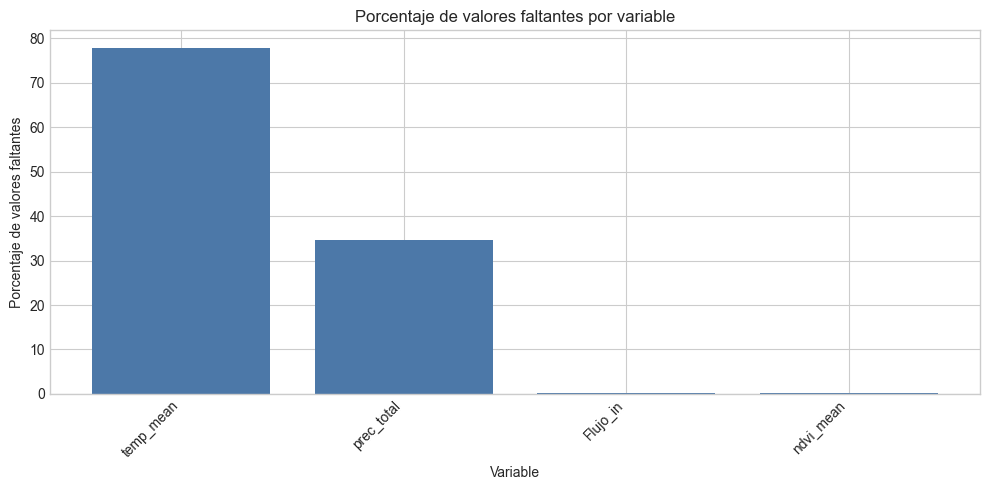

In [145]:
# Visualización de valores faltantes
missing_values_plot = missing_values[missing_values["valores_faltantes"] > 0]

if missing_values_plot.empty:
    print("No se encontraron valores faltantes en el dataset.")
else:
    plt.figure(figsize=(10, 5))
    plt.bar(
        missing_values_plot.index,
        missing_values_plot["porcentaje_faltantes"],
        color="#4C78A8",
    )
    plt.title("Porcentaje de valores faltantes por variable")
    plt.xlabel("Variable")
    plt.ylabel("Porcentaje de valores faltantes")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 10. Validación de Integridad Lógica de Datos

Se verifican consistencias lógicas críticas para análisis y mejora de datos: la suma de grupos etarios, la suma por sexo, rangos válidos y ausencia de valores imposibles. La estratificación socioeconómica se evalúa como cobertura parcial, no como error crítico, porque no necesariamente representa una desagregación completa de `casos_totales`.


In [147]:
integrity_checks = []

# Validación 1: los grupos etarios suman los casos totales
age_group_cols = ["casos_0_4", "casos_5_14", "casos_15_64", "casos_65_plus"]
age_sum = df[age_group_cols].sum(axis=1)
age_sum_mismatch = (age_sum != df["casos_totales"]).sum()
integrity_checks.append({
    "Validación": "Los grupos etarios suman los casos totales",
    "Filas fallidas": age_sum_mismatch,
    "Resultado": "PASA" if age_sum_mismatch == 0 else "FALLA",
    "Impacto": "Alto" if age_sum_mismatch > 0 else "-",
})

# Validación 2: los grupos por sexo suman los casos totales
sex_cols = ["casos_m", "casos_f"]
sex_sum = df[sex_cols].sum(axis=1)
sex_sum_mismatch = (sex_sum != df["casos_totales"]).sum()
integrity_checks.append({
    "Validación": "Los grupos por sexo suman los casos totales",
    "Filas fallidas": sex_sum_mismatch,
    "Resultado": "PASA" if sex_sum_mismatch == 0 else "FALLA",
    "Impacto": "Alto" if sex_sum_mismatch > 0 else "-",
})

# Validación 3: casos no negativos
negative_cases = (df["casos_totales"] < 0).sum()
integrity_checks.append({
    "Validación": "Todos los casos son no negativos",
    "Filas fallidas": negative_cases,
    "Resultado": "PASA" if negative_cases == 0 else "FALLA",
    "Impacto": "Crítico" if negative_cases > 0 else "-",
})

# Validación 4: variables ambientales en rangos válidos
temp_out_of_range = ((df["temp_mean"] < -50) | (df["temp_mean"] > 50)).sum()
integrity_checks.append({
    "Validación": "Temperatura en rango válido (-50 °C a 50 °C)",
    "Filas fallidas": temp_out_of_range,
    "Resultado": "PASA" if temp_out_of_range == 0 else "FALLA",
    "Impacto": "Medio" if temp_out_of_range > 0 else "-",
})

# Validación 5: precipitación no negativa
negative_prec = (df["prec_total"] < 0).sum()
integrity_checks.append({
    "Validación": "Precipitación no negativa",
    "Filas fallidas": negative_prec,
    "Resultado": "PASA" if negative_prec == 0 else "FALLA",
    "Impacto": "Medio" if negative_prec > 0 else "-",
})

# Validación 6: población no nula
zero_pop = (df["poblacion"] == 0).sum()
integrity_checks.append({
    "Validación": "Población no nula",
    "Filas fallidas": zero_pop,
    "Resultado": "PASA" if zero_pop == 0 else "FALLA",
    "Impacto": "Medio" if zero_pop > 0 else "-",
})

In [148]:
# Fechas dentro del rango esperado
integrity_df = pd.DataFrame(integrity_checks)
display(integrity_df)

,Validación,Filas fallidas,Resultado,Impacto
0,Los grupos etarios suman los casos totales,0,PASA,-
1,Los grupos por sexo suman los casos totales,0,PASA,-
2,Todos los casos son no negativos,0,PASA,-
3,Temperatura en rango válido (-50 °C a 50 °C),0,PASA,-
4,Precipitación no negativa,0,PASA,-
5,Población no nula,0,PASA,-


In [149]:
# Cobertura parcial de estratos socioeconómicos
strata_cols = ["estrato_1_2", "estrato_3_4", "estrato_5_plus"]
strata_sum = df[strata_cols].sum(axis=1)
strata_mismatch_rows = (strata_sum != df["casos_totales"]).sum()
strata_cases_covered = df[strata_cols].sum().sum()
total_cases = df["casos_totales"].sum()
strata_coverage_pct = (strata_cases_covered / total_cases * 100) if total_cases > 0 else 0

strata_coverage_df = pd.DataFrame({
    "Métrica": [
        "Casos cubiertos por estratos",
        "Casos totales del dataset",
        "Cobertura de estratos (%)",
        "Filas donde estratos no suman casos_totales",
        "Interpretación",
    ],
    "Valor": [
        f"{int(strata_cases_covered):,}",
        f"{int(total_cases):,}",
        round(strata_coverage_pct, 2),
        f"{strata_mismatch_rows:,}",
        "Cobertura parcial; no tratar como error crítico ni como desagregación completa",
    ],
})

display(Markdown("### Cobertura parcial de estratos socioeconómicos"))
display(strata_coverage_df)

### Cobertura parcial de estratos socioeconómicos

,Métrica,Valor
0,Casos cubiertos por estratos,"708,595"
1,Casos totales del dataset,"1,499,841"
2,Cobertura de estratos (%),47.24
3,Filas donde estratos no suman casos_totales,"109,142"
4,Interpretación,Cobertura parcial; no tratar como error crític...


In [150]:
# Resumen de integridad de datos
total_checks = len(integrity_checks)
passed_checks = (integrity_df["Resultado"] == "PASA").sum()
integrity_status = (
    "Datos consistentes para análisis exploratorio y mejora de datos."
    if passed_checks == total_checks
    else "Advertencia: se detectaron problemas de integridad que deben revisarse."
)

integrity_summary_df = pd.DataFrame({
    "Métrica": ["Validaciones críticas aprobadas", "Estado"],
    "Valor": [f"{passed_checks}/{total_checks}", integrity_status],
})

display(integrity_summary_df)

failed_checks = integrity_df[integrity_df["Resultado"] == "FALLA"]
if not failed_checks.empty:
    display(Markdown("### Validaciones críticas fallidas"))
    display(failed_checks)

,Métrica,Valor
0,Validaciones críticas aprobadas,6/6
1,Estado,Datos consistentes para análisis exploratorio ...


## 11. Caracterización de la Variable Principal de Análisis (Casos Totales)

Se analiza la distribución de `casos_totales`, la variable principal de análisis epidemiológico. El objetivo es describir su rango, concentración de ceros, asimetría y semanas de alta incidencia para orientar el análisis exploratorio y la mejora de datos.


In [151]:
cases_data = df["casos_totales"]

# Estadísticas descriptivas
cases_stats = {
    "Casos totales": f"{cases_data.sum():,}",
    "Media de casos por semana-municipio": round(cases_data.mean(), 2),
    "Mediana": int(cases_data.median()),
    "Desviación estándar": round(cases_data.std(), 2),
    "Mínimo": int(cases_data.min()),
    "Máximo": int(cases_data.max()),
    "Q25 (percentil 25)": int(cases_data.quantile(0.25)),
    "Q75 (percentil 75)": int(cases_data.quantile(0.75)),
    "Q95 (percentil 95)": int(cases_data.quantile(0.95)),
    "Q99 (percentil 99)": int(cases_data.quantile(0.99)),
}

cases_df = pd.DataFrame(list(cases_stats.items()), columns=["Estadística", "Valor"])
display(cases_df)

,Estadística,Valor
0,Casos totales,"1,499,841"
1,Media de casos por semana-municipio,1.84
2,Mediana,0
3,Desviación estándar,15.24
4,Mínimo,0
5,Máximo,1426
6,Q25 (percentil 25),0
7,Q75 (percentil 75),0
8,Q95 (percentil 95),6
9,Q99 (percentil 99),32


In [152]:
# Análisis de concentración de ceros
num_zeros = (cases_data == 0).sum()
pct_zeros = (num_zeros / len(cases_data)) * 100

if pct_zeros > 50:
    zero_interpretation = "Exceso de ceros: describir por separado presencia/ausencia e intensidad de casos."
elif pct_zeros > 30:
    zero_interpretation = "Alta concentración de ceros: revisar visualizaciones con escala logarítmica."
else:
    zero_interpretation = "Concentración moderada de ceros: análisis descriptivo estándar aplicable."

zero_inflation_df = pd.DataFrame({
    "Métrica": ["Semanas con 0 casos", "Semanas con 1+ casos", "Interpretación"],
    "Valor": [
        f"{num_zeros:,} ({pct_zeros:.1f}%)",
        f"{len(cases_data) - num_zeros:,} ({100 - pct_zeros:.1f}%)",
        zero_interpretation,
    ],
})

display(Markdown("### Análisis de concentración de ceros"))
display(zero_inflation_df)

### Análisis de concentración de ceros

,Métrica,Valor
0,Semanas con 0 casos,"631,201 (77.6%)"
1,Semanas con 1+ casos,"182,079 (22.4%)"
2,Interpretación,Exceso de ceros: describir por separado presen...


In [153]:
# Asimetría y curtosis
skewness = skew(cases_data)
kurt = kurtosis(cases_data)

if abs(skewness) > 1:
    skew_interpretation = "Distribución altamente sesgada a la derecha; considerar escala logarítmica para visualización."
elif abs(skewness) > 0.5:
    skew_interpretation = "Distribución moderadamente sesgada a la derecha; revisar visualizaciones alternativas."
else:
    skew_interpretation = "Distribución aproximadamente simétrica."

distribution_shape_df = pd.DataFrame({
    "Métrica": ["Asimetría", "Curtosis", "Interpretación"],
    "Valor": [round(skewness, 2), round(kurt, 2), skew_interpretation],
})

display(Markdown("### Forma de la distribución"))
display(distribution_shape_df)

### Forma de la distribución

,Métrica,Valor
0,Asimetría,33.37
1,Curtosis,1811.96
2,Interpretación,Distribución altamente sesgada a la derecha; c...


In [154]:
# Semanas de alta incidencia por percentiles altos
high_incidence_thresholds = {
    "Percentil 95": cases_data.quantile(0.95),
    "Percentil 99": cases_data.quantile(0.99),
    "Máximo": cases_data.max(),
}

high_incidence_df = pd.DataFrame({
    "Criterio": list(high_incidence_thresholds.keys()),
    "Valor de casos": [int(value) for value in high_incidence_thresholds.values()],
    "Observaciones en o por encima del valor": [
        f"{(cases_data >= value).sum():,}" for value in high_incidence_thresholds.values()
    ],
})

high_incidence_note_df = pd.DataFrame({
    "Nota metodológica": [
        "No se usa IQR como criterio principal porque Q1 y Q3 son 0; en este dataset marcaría cualquier valor positivo como atípico."
    ]
})

display(Markdown("### Semanas de alta incidencia"))
display(high_incidence_df)
display(high_incidence_note_df)

### Semanas de alta incidencia

,Criterio,Valor de casos,Observaciones en o por encima del valor
0,Percentil 95,6,"43,474"
1,Percentil 99,32,"8,316"
2,Máximo,1426,1


,Nota metodológica
0,No se usa IQR como criterio principal porque Q...


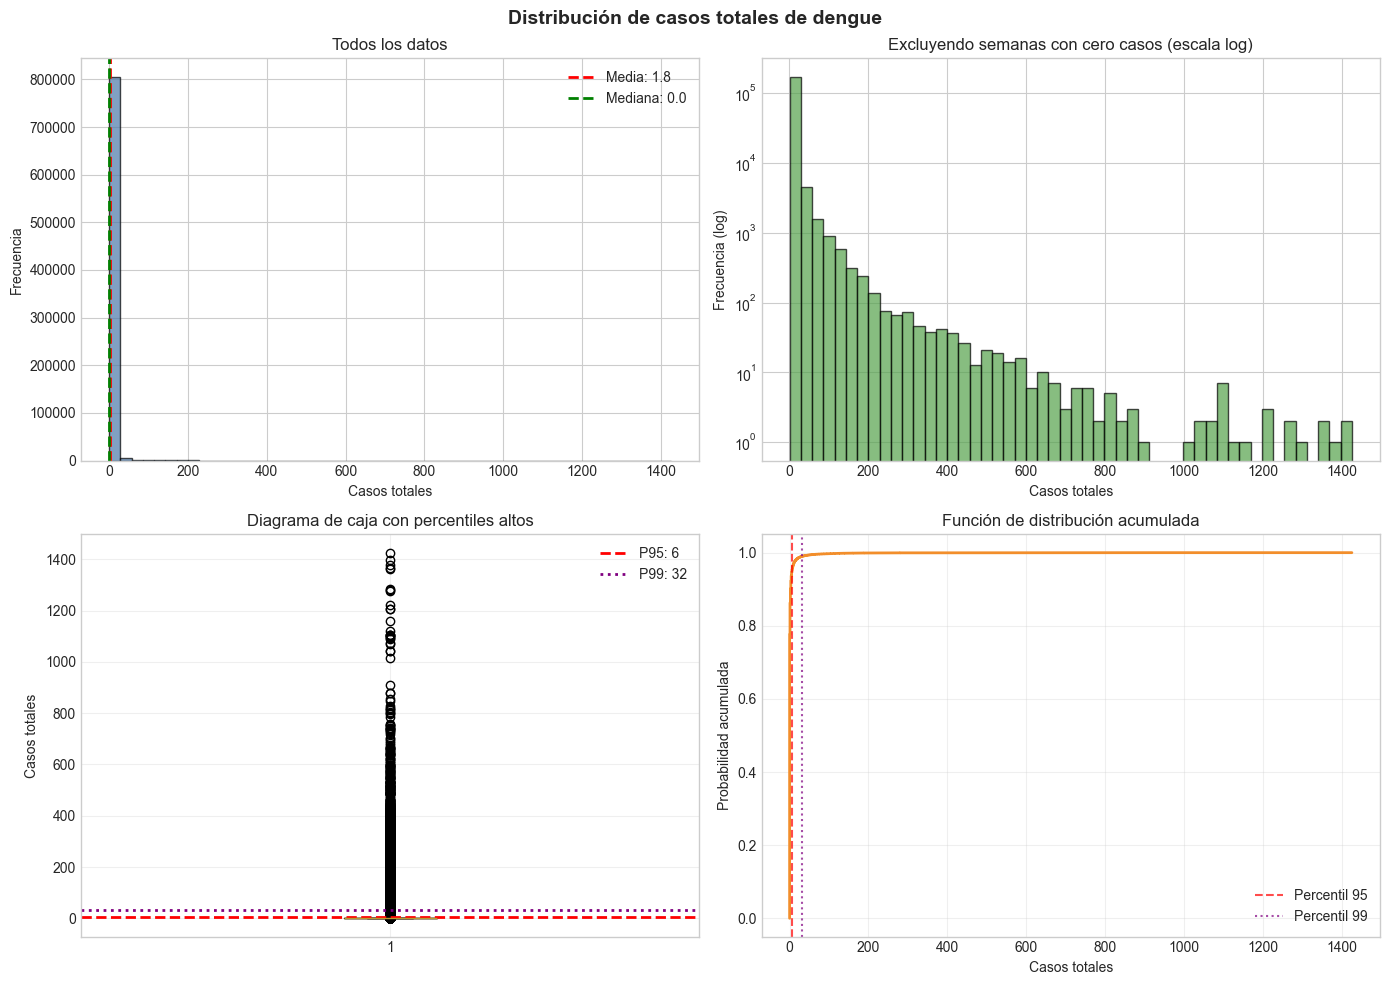

In [155]:
# Visualización de la distribución
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribución de casos totales de dengue", fontsize=14, fontweight="bold")

# Histograma con todos los datos
axes[0, 0].hist(cases_data, bins=50, color="#4C78A8", edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Todos los datos")
axes[0, 0].set_xlabel("Casos totales")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].axvline(cases_data.mean(), color="red", linestyle="--", linewidth=2, label=f"Media: {cases_data.mean():.1f}")
axes[0, 0].axvline(cases_data.median(), color="green", linestyle="--", linewidth=2, label=f"Mediana: {cases_data.median():.1f}")
axes[0, 0].legend()

# Histograma excluyendo ceros
cases_nonzero = cases_data[cases_data > 0]
axes[0, 1].hist(cases_nonzero, bins=50, color="#54A24B", edgecolor="black", alpha=0.7)
axes[0, 1].set_title("Excluyendo semanas con cero casos (escala log)")
axes[0, 1].set_xlabel("Casos totales")
axes[0, 1].set_ylabel("Frecuencia (log)")
axes[0, 1].set_yscale("log")

# Diagrama de caja
axes[1, 0].boxplot(cases_data, vert=True)
axes[1, 0].axhline(y=cases_data.quantile(0.95), color="red", linestyle="--", linewidth=2, label=f"P95: {cases_data.quantile(0.95):.0f}")
axes[1, 0].axhline(y=cases_data.quantile(0.99), color="purple", linestyle=":", linewidth=2, label=f"P99: {cases_data.quantile(0.99):.0f}")
axes[1, 0].set_title("Diagrama de caja con percentiles altos")
axes[1, 0].set_ylabel("Casos totales")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Distribución acumulada
sorted_cases = np.sort(cases_data)
cumulative = np.arange(1, len(sorted_cases) + 1) / len(sorted_cases)
axes[1, 1].plot(sorted_cases, cumulative, linewidth=2, color="#F28E2B")
axes[1, 1].axvline(cases_data.quantile(0.95), color="red", linestyle="--", linewidth=1.5, alpha=0.7, label="Percentil 95")
axes[1, 1].axvline(cases_data.quantile(0.99), color="purple", linestyle=":", linewidth=1.5, alpha=0.7, label="Percentil 99")
axes[1, 1].set_title("Función de distribución acumulada")
axes[1, 1].set_xlabel("Casos totales")
axes[1, 1].set_ylabel("Probabilidad acumulada")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Diccionario de Variables y Contexto Epidemiológico

Se documenta cada variable para garantizar comprensión y reproducibilidad. El diccionario usa lenguaje descriptivo orientado a entendimiento, análisis y mejora de datos, y aclara cuando una variable representa cobertura parcial.


In [156]:
# DICCIONARIO DE VARIABLES
variable_dictionary = {
    "COD_MUN_N": {
        "Tipo": "Entero (ID)",
        "Rol": "Identificador geográfico",
        "Descripción": "Código municipal colombiano (formato DIVIPOLA)",
        "Rango": f"{df['COD_MUN_N'].min()}-{df['COD_MUN_N'].max()}",
        "Faltantes": "0.0%"
    },
    "ANO": {
        "Tipo": "Entero",
        "Rol": "Identificador temporal",
        "Descripción": "Año epidemiológico",
        "Rango": f"{df['ANO'].min()}-{df['ANO'].max()}",
        "Faltantes": "0.0%"
    },
    "SEMANA": {
        "Tipo": "Entero",
        "Rol": "Identificador temporal",
        "Descripción": "Semana epidemiológica (1-53)",
        "Rango": f"{df['SEMANA'].min()}-{df['SEMANA'].max()}",
        "Faltantes": "0.0%"
    },
    "week_date": {
        "Tipo": "Fecha/hora",
        "Rol": "Variable temporal (construida)",
        "Descripción": "Fecha de inicio semanal tomada de week_start",
        "Rango": f"{df['week_date'].min().date()}-{df['week_date'].max().date()}",
        "Faltantes": f"{df['week_date'].isna().sum() / len(df) * 100:.1f}%"
    },
    "casos_totales": {
        "Tipo": "Entero (conteo)",
        "Rol": "Variable principal de análisis",
        "Descripción": "Total de casos de dengue reportados en municipio-semana",
        "Rango": f"{df['casos_totales'].min()}-{df['casos_totales'].max()}",
        "Faltantes": "0.0%"
    },
    "casos_0_4": {
        "Tipo": "Entero (conteo)",
        "Rol": "Secundaria - Estratificación por edad",
        "Descripción": "Casos de dengue en edades 0-4 años",
        "Rango": f"{df['casos_0_4'].min()}-{df['casos_0_4'].max()}",
        "Faltantes": "0.0%"
    },
    "casos_5_14": {
        "Tipo": "Entero (conteo)",
        "Rol": "Secundaria - Estratificación por edad",
        "Descripción": "Casos de dengue en edades 5-14 años",
        "Rango": f"{df['casos_5_14'].min()}-{df['casos_5_14'].max()}",
        "Faltantes": "0.0%"
    },
    "casos_15_64": {
        "Tipo": "Entero (conteo)",
        "Rol": "Secundaria - Estratificación por edad",
        "Descripción": "Casos de dengue en edades 15-64 años",
        "Rango": f"{df['casos_15_64'].min()}-{df['casos_15_64'].max()}",
        "Faltantes": "0.0%"
    },
    "casos_65_plus": {
        "Tipo": "Entero (conteo)",
        "Rol": "Secundaria - Estratificación por edad",
        "Descripción": "Casos de dengue en edades 65+ años",
        "Rango": f"{df['casos_65_plus'].min()}-{df['casos_65_plus'].max()}",
        "Faltantes": "0.0%"
    },
    "casos_m": {
        "Tipo": "Entero (conteo)",
        "Rol": "Secundaria - Estratificación por sexo",
        "Descripción": "Casos de dengue en hombres",
        "Rango": f"{df['casos_m'].min()}-{df['casos_m'].max()}",
        "Faltantes": "0.0%"
    },
    "casos_f": {
        "Tipo": "Entero (conteo)",
        "Rol": "Secundaria - Estratificación por sexo",
        "Descripción": "Casos de dengue en mujeres",
        "Rango": f"{df['casos_f'].min()}-{df['casos_f'].max()}",
        "Faltantes": "0.0%"
    },
    "estrato_1_2": {
        "Tipo": "Entero (conteo)",
        "Rol": "Variable socioeconómica de cobertura parcial",
        "Descripción": "Casos con registro en estratos socioeconómicos 1-2; cobertura parcial respecto a casos_totales",
        "Rango": f"{df['estrato_1_2'].min()}-{df['estrato_1_2'].max()}",
        "Faltantes": "0.0%"
    },
    "estrato_3_4": {
        "Tipo": "Entero (conteo)",
        "Rol": "Variable socioeconómica de cobertura parcial",
        "Descripción": "Casos con registro en estratos socioeconómicos 3-4; cobertura parcial respecto a casos_totales",
        "Rango": f"{df['estrato_3_4'].min()}-{df['estrato_3_4'].max()}",
        "Faltantes": "0.0%"
    },
    "estrato_5_plus": {
        "Tipo": "Entero (conteo)",
        "Rol": "Variable socioeconómica de cobertura parcial",
        "Descripción": "Casos con registro en estratos socioeconómicos 5+; cobertura parcial respecto a casos_totales",
        "Rango": f"{df['estrato_5_plus'].min()}-{df['estrato_5_plus'].max()}",
        "Faltantes": "0.0%"
    },
    "MES": {
        "Tipo": "Entero",
        "Rol": "Temporal - Mes",
        "Descripción": "Mes calendario (1=ene, 12=dic)",
        "Rango": f"{df['MES'].min()}-{df['MES'].max()}",
        "Faltantes": "0.0%"
    },
    "temp_mean": {
        "Tipo": "Decimal (°C)",
        "Rol": "Variable climática",
        "Descripción": "Temperatura media (promedio semanal de satélite/estaciones)",
        "Rango": f"{df['temp_mean'].min():.1f} deg C - {df['temp_mean'].max():.1f} deg C",
        "Faltantes": f"{df['temp_mean'].isna().sum() / len(df) * 100:.1f}%"
    },
    "prec_total": {
        "Tipo": "Decimal (mm)",
        "Rol": "Variable climática",
        "Descripción": "Precipitación total (acumulado semanal)",
        "Rango": f"{df['prec_total'].min():.1f}mm - {df['prec_total'].max():.1f}mm",
        "Faltantes": f"{df['prec_total'].isna().sum() / len(df) * 100:.1f}%"
    },
    "ndvi_mean": {
        "Tipo": "Decimal (Índice)",
        "Rol": "Variable ambiental",
        "Descripción": "Índice de vegetación de diferencia normalizada (densidad vegetal, rango 0-1)",
        "Rango": f"{df['ndvi_mean'].min():.3f} - {df['ndvi_mean'].max():.3f}",
        "Faltantes": f"{df['ndvi_mean'].isna().sum() / len(df) * 100:.1f}%"
    },
    "oni_anom": {
        "Tipo": "Decimal (anomalía)",
        "Rol": "Variable climática oceánica",
        "Descripción": "Anomalía del Índice Niño oceánico (proxy de El Niño/La Niña)",
        "Rango": f"{df['oni_anom'].min():.2f} - {df['oni_anom'].max():.2f}",
        "Faltantes": "0.0%"
    },
    "oni_total": {
        "Tipo": "Decimal (Índice)",
        "Rol": "Variable climática oceánica",
        "Descripción": "Índice Niño oceánico (valor absoluto)",
        "Rango": f"{df['oni_total'].min():.2f} - {df['oni_total'].max():.2f}",
        "Faltantes": "0.0%"
    },
    "Flujo_in": {
        "Tipo": "Decimal (Índice/flujo)",
        "Rol": "Variable de movilidad",
        "Descripción": "Indicador de movilidad entrante (movimiento humano hacia el municipio)",
        "Rango": f"{df['Flujo_in'].min():.2f} - {df['Flujo_in'].max():.2f}",
        "Faltantes": f"{df['Flujo_in'].isna().sum() / len(df) * 100:.1f}%"
    },
    "poblacion": {
        "Tipo": "Entero (conteo)",
        "Rol": "Variable demográfica",
        "Descripción": "Población municipal (anual)",
        "Rango": f"{df['poblacion'].min():,} - {df['poblacion'].max():,}",
        "Faltantes": "0.0%"
    }
}

dict_df = pd.DataFrame(variable_dictionary).T
dict_df = dict_df.reset_index().rename(columns={"index": "Variable"})

dict_df

,Variable,Tipo,Rol,Descripción,Rango,Faltantes
0,COD_MUN_N,Entero (ID),Identificador geográfico,Código municipal colombiano (formato DIVIPOLA),5001-99773,0.0%
1,ANO,Entero,Identificador temporal,Año epidemiológico,2010-2024,0.0%
2,SEMANA,Entero,Identificador temporal,Semana epidemiológica (1-53),1-53,0.0%
3,week_date,Fecha/hora,Variable temporal (construida),Fecha de inicio semanal tomada de week_start,2010-01-04-2024-12-23,0.0%
4,casos_totales,Entero (conteo),Variable principal de análisis,Total de casos de dengue reportados en municip...,0-1426,0.0%
5,casos_0_4,Entero (conteo),Secundaria - Estratificación por edad,Casos de dengue en edades 0-4 años,0-95,0.0%
6,casos_5_14,Entero (conteo),Secundaria - Estratificación por edad,Casos de dengue en edades 5-14 años,0-421,0.0%
7,casos_15_64,Entero (conteo),Secundaria - Estratificación por edad,Casos de dengue en edades 15-64 años,0-839,0.0%
8,casos_65_plus,Entero (conteo),Secundaria - Estratificación por edad,Casos de dengue en edades 65+ años,0-107,0.0%
9,casos_m,Entero (conteo),Secundaria - Estratificación por sexo,Casos de dengue en hombres,0-707,0.0%


## 13. Síntesis: Problemas Identificados y Preparación para Análisis Exploratorio y Mejora de Datos

La síntesis resume la calidad estructural del dataset, las características epidemiológicas principales y las alertas que deben considerarse en los siguientes pasos de análisis exploratorio y mejora de datos.


In [157]:
# RESUMEN DE CALIDAD ESTRUCTURAL
structural_quality_df = pd.DataFrame({
    "Aspecto": ["Panel", "Duplicados", "Fechas", "Completitud"],
    "Hallazgo": [
        f"{completeness_df['Completitud (%)'].mean():.1f}% completo por año observado",
        f"{duplicate_key_count} duplicados en la clave panel",
        f"week_date coincide {week_start_match_pct}% con week_start",
        f"{df.isna().sum().sum():,} valores faltantes en total",
    ],
    "Implicación": [
        "Estructura adecuada para análisis temporal exploratorio",
        "No se detectan duplicados críticos" if duplicate_key_count == 0 else "Revisar duplicados antes de continuar",
        "Se conserva la fecha semanal provista por el dataset",
        "Revisar variables con faltantes antes de análisis comparativos",
    ],
})

display(Markdown("### Resumen de calidad estructural"))
display(structural_quality_df)

### Resumen de calidad estructural

,Aspecto,Hallazgo,Implicación
0,Panel,100.0% completo por año observado,Estructura adecuada para análisis temporal exp...
1,Duplicados,0 duplicados en la clave panel,No se detectan duplicados críticos
2,Fechas,week_date coincide 100.0% con week_start,Se conserva la fecha semanal provista por el d...
3,Completitud,"916,416 valores faltantes en total",Revisar variables con faltantes antes de análi...


In [158]:
# RESUMEN EPIDEMIOLÓGICO
epidemiological_summary_df = pd.DataFrame({
    "Característica": [
        "Casos totales",
        "Media por municipio-semana",
        "% semanas con 0 casos",
        "P95",
        "P99",
        "Máximo",
        "Asimetría",
    ],
    "Valor": [
        f"{cases_data.sum():,}",
        f"{cases_data.mean():.2f} casos",
        f"{pct_zeros:.1f}%",
        f"{int(cases_data.quantile(0.95))} casos",
        f"{int(cases_data.quantile(0.99))} casos",
        f"{int(cases_data.max()):,} casos",
        f"{skewness:.2f}",
    ],
    "Implicación": [
        "Carga epidémica documentada significativa",
        f"Alta variabilidad: de {int(cases_data.min())} a {int(cases_data.max()):,}",
        "Conviene separar presencia/ausencia e intensidad",
        "Referencia para semanas de alta incidencia",
        "Referencia para episodios extremos",
        "Máximo observado del periodo",
        "Distribución altamente sesgada; usar escala logarítmica en visualizaciones cuando ayude",
    ],
})

display(Markdown("### Resumen epidemiológico"))
display(epidemiological_summary_df)

### Resumen epidemiológico

,Característica,Valor,Implicación
0,Casos totales,"1,499,841",Carga epidémica documentada significativa
1,Media por municipio-semana,1.84 casos,"Alta variabilidad: de 0 a 1,426"
2,% semanas con 0 casos,77.6%,Conviene separar presencia/ausencia e intensidad
3,P95,6 casos,Referencia para semanas de alta incidencia
4,P99,32 casos,Referencia para episodios extremos
5,Máximo,"1,426 casos",Máximo observado del periodo
6,Asimetría,33.37,Distribución altamente sesgada; usar escala lo...


In [159]:
# RESUMEN DE CALIDAD DE VARIABLES CLIMÁTICAS Y AMBIENTALES
climate_missing_pct = {
    "temp_mean": df["temp_mean"].isna().mean() * 100,
    "prec_total": df["prec_total"].isna().mean() * 100,
    "ndvi_mean": df["ndvi_mean"].isna().mean() * 100,
}

improvement_alerts_df = pd.DataFrame({
    "Alerta": [
        "Faltantes climáticos y ambientales",
        "Cobertura parcial de estratos",
        "Interpretación de valores atípicos",
    ],
    "Evidencia": [
        ", ".join([f"{var}: {pct:.1f}%" for var, pct in climate_missing_pct.items()]),
        f"Estratos cubren {strata_coverage_pct:.1f}% de casos y difieren de casos_totales en {strata_mismatch_rows:,} filas",
        "Q1 y Q3 de casos_totales son 0; IQR marcaría cualquier caso positivo como atípico",
    ],
    "Acción sugerida": [
        "Documentar patrón de faltantes y decidir tratamiento en notebook de mejora de datos",
        "Tratar estratos como información parcial; evitar porcentajes como distribución completa",
        "Usar percentiles altos y visualizaciones en escala logarítmica para describir alta incidencia",
    ],
})

display(Markdown("### Alertas para mejora de datos"))
display(improvement_alerts_df)

### Alertas para mejora de datos

,Alerta,Evidencia,Acción sugerida
0,Faltantes climáticos y ambientales,"temp_mean: 77.9%, prec_total: 34.6%, ndvi_mean...",Documentar patrón de faltantes y decidir trata...
1,Cobertura parcial de estratos,Estratos cubren 47.2% de casos y difieren de c...,Tratar estratos como información parcial; evit...
2,Interpretación de valores atípicos,Q1 y Q3 de casos_totales son 0; IQR marcaría c...,Usar percentiles altos y visualizaciones en es...


## Almacenar tablas


In [163]:
dataset_overview = pd.DataFrame(
    summary_dict.items(),
    columns=["Métrica", "Valor"],
)

dataset_overview.to_csv(
    TABLES_PATH / "dataset_overview.csv",
    index=False,
    encoding="utf-8-sig",
)

completeness_df.to_csv(
    TABLES_PATH / "panel_completeness_by_year.csv",
    index=False,
    encoding="utf-8-sig",
)

missing_values.to_csv(
    TABLES_PATH / "missing_values_summary.csv",
    index=True,
    encoding="utf-8-sig",
)

integrity_df.to_csv(
    TABLES_PATH / "integrity_checks.csv",
    index=False,
    encoding="utf-8-sig",
)

dict_df.to_csv(
    TABLES_PATH / "variable_dictionary.csv",
    index=False,
    encoding="utf-8-sig",
)

improvement_alerts_df.to_csv(
    TABLES_PATH / "key_alerts_for_next_steps.csv",
    index=False,
    encoding="utf-8-sig",
)